In [1]:
from trees.causal_forest import parameter_tuning
from trees.topk import *

 50%|█████     | 1/2 [03:06<03:06, 186.78s/it]2025-01-16 11:27:02.629 | WARNING  | trees.topk:get_topK:88 - [Hybrid] CF - ConstrainedJ - |t_r-t|=0.1689999999999996 are different. P: feature_9 <= -0.292 Subgroup: feature_0 > -0.056 AND feature_0 > 0.917 AND feature_1 > 0.854 AND feature_0 > 1.472 AND feature_1 > 1.327 AND feature_0 > 1.701 AND feature_1 > 1.852 AND feature_0 > 1.773 AND feature_1 > 1.943 AND feature_0 > 1.908
2025-01-16 11:27:02.716 | WARNING  | trees.topk:get_topK:88 - [Hybrid] CF - Weighted - |t_r-t|=0.1689999999999996 are different. P: feature_9 <= -0.292 Subgroup: feature_0 > -0.056 AND feature_0 > 0.917 AND feature_1 > 0.854 AND feature_0 > 1.472 AND feature_1 > 1.327 AND feature_0 > 1.701 AND feature_1 > 1.852 AND feature_0 > 1.773 AND feature_1 > 1.943 AND feature_0 > 1.908
2025-01-16 11:27:02.814 | WARNING  | trees.topk:get_topK:88 - [Hybrid] CF - ConstrainedT - |t_r-t|=0.1689999999999996 are different. P: feature_9 <= -0.292 Subgroup: feature_0 > -0.056 AND fea

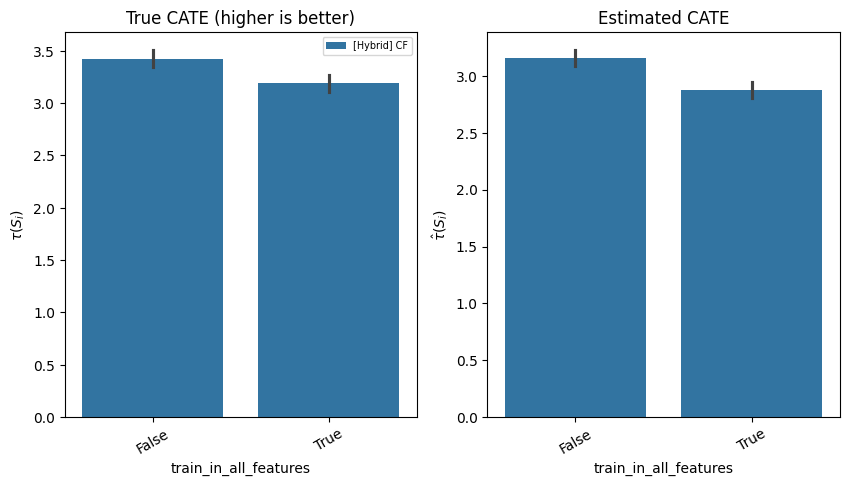

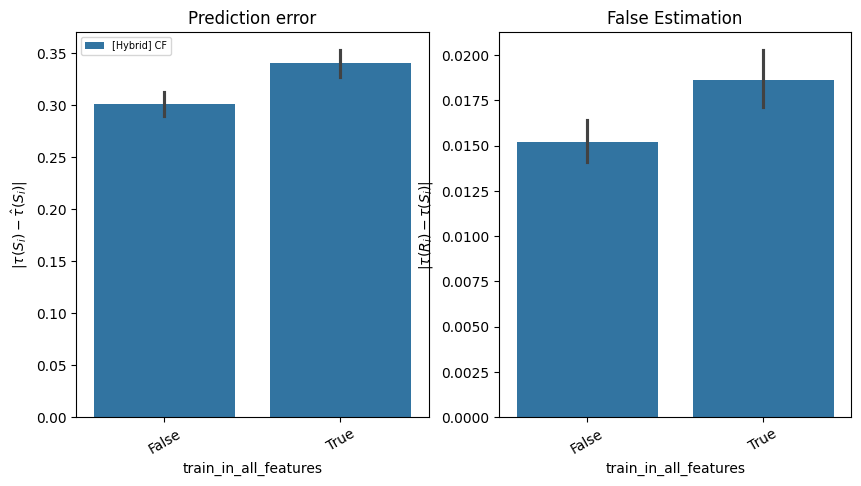

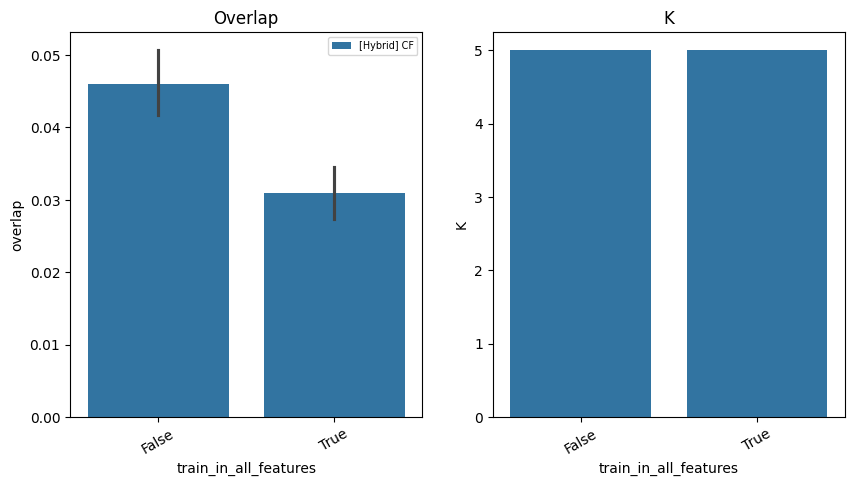

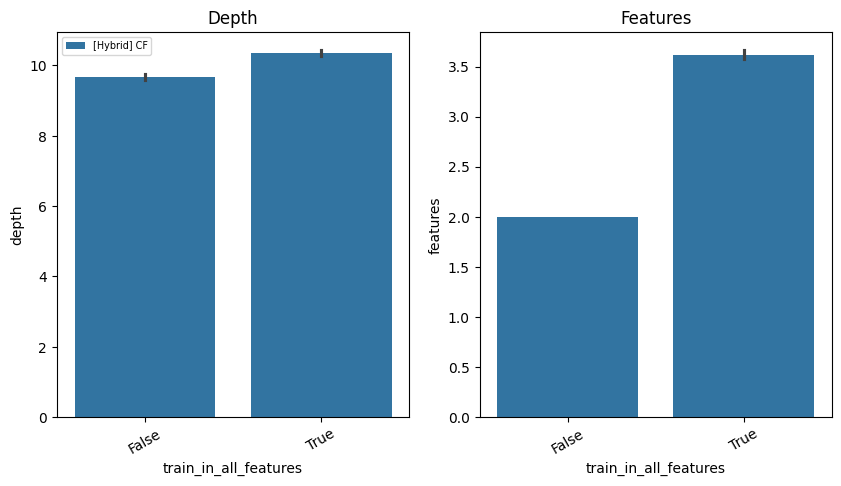

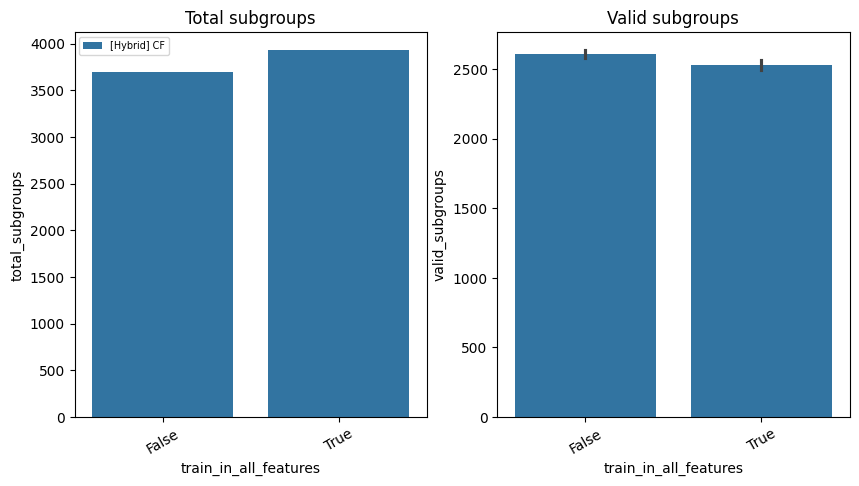

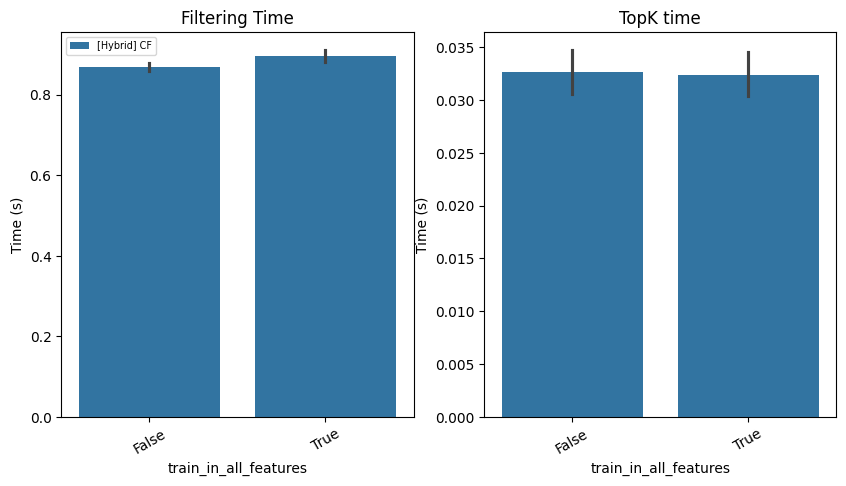

In [2]:
parameter_tuning("train_in_all_features", [True, False], user_iterations=50, scanners = main_competitors)

# Cross-Validation

cv (int, cross-validation generator or an iterable, default 2) Determines the cross-validation splitting strategy. Possible inputs for cv are:

- None, to use the default 3-fold cross-validation,

- integer, to specify the number of folds.

- CV splitter

- An iterable yielding (train, test) splits as arrays of indices.

For integer/None inputs, if the treatment is discrete StratifiedKFold is used, else, KFold is used (with a random shuffle in either case).

Unless an iterable is used, we call split(X,T) to generate the splits.


 40%|████      | 2/5 [02:58<04:28, 89.65s/it]2024-12-20 15:53:47.278 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - ConstrainedJ - |t_r-t|=0.16199999999999992 are different. P: feature_3 > 0.539 Subgroup: feature_0 > 0.35 AND feature_0 > 1.026 AND feature_1 > 0.178 AND feature_1 > 1.286
2024-12-20 15:53:47.303 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - ConstrainedT - |t_r-t|=0.16199999999999992 are different. P: feature_3 > 0.539 Subgroup: feature_0 > 0.35 AND feature_0 > 1.026 AND feature_1 > 0.178 AND feature_1 > 1.286
2024-12-20 15:53:47.330 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - Weighted - |t_r-t|=0.16199999999999992 are different. P: feature_3 > 0.539 Subgroup: feature_0 > 0.35 AND feature_0 > 1.026 AND feature_1 > 0.178 AND feature_1 > 1.286
 60%|██████    | 3/5 [04:37<03:08, 94.10s/it]2024-12-20 15:55:40.507 | WARNING  | trees.topk:scan:243 - [Hybrid] CF - ConstrainedJ -  Not enough valid subgroups to satisfy max_overlap=0.5
2024-12-20 15:55:40.508 | W

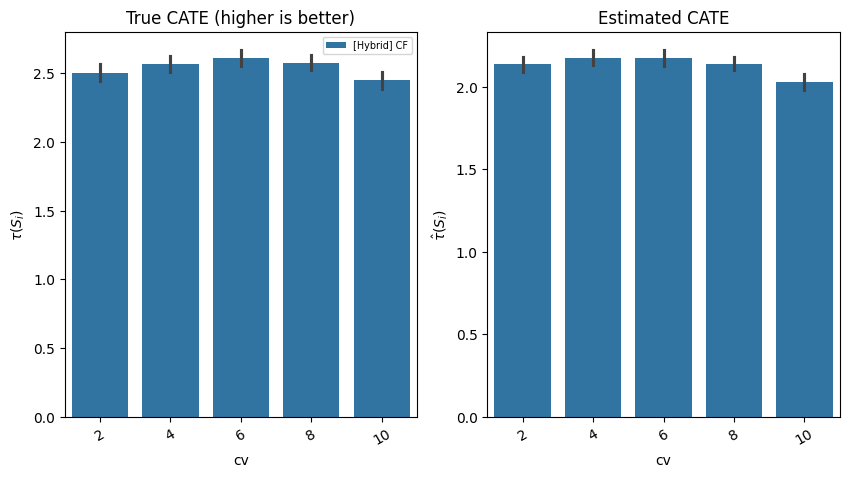

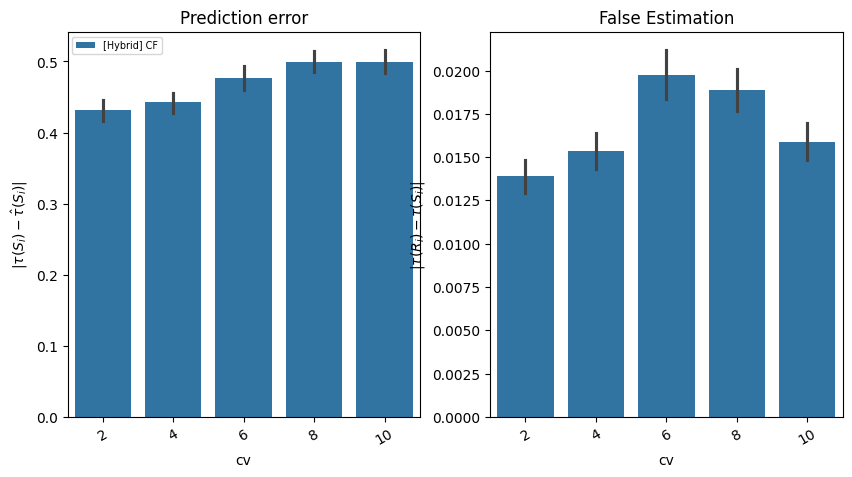

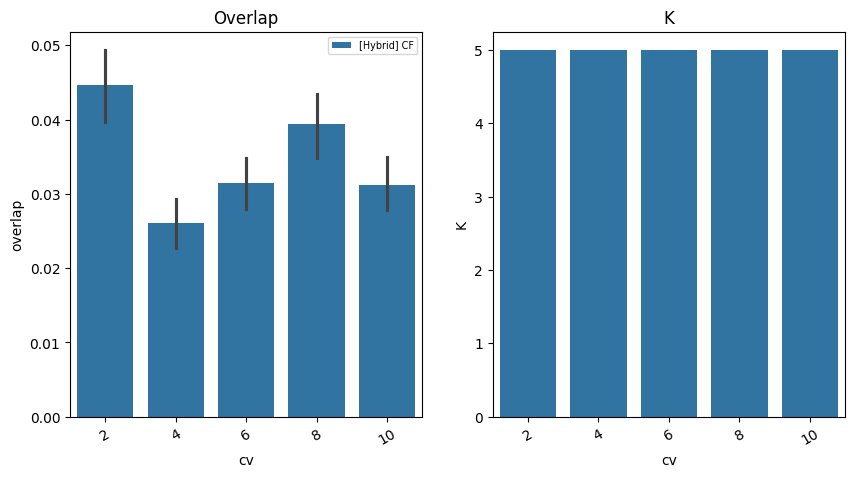

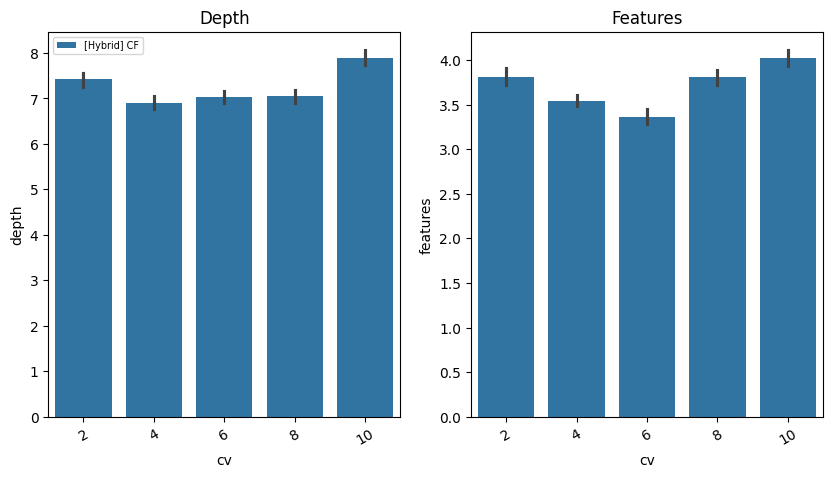

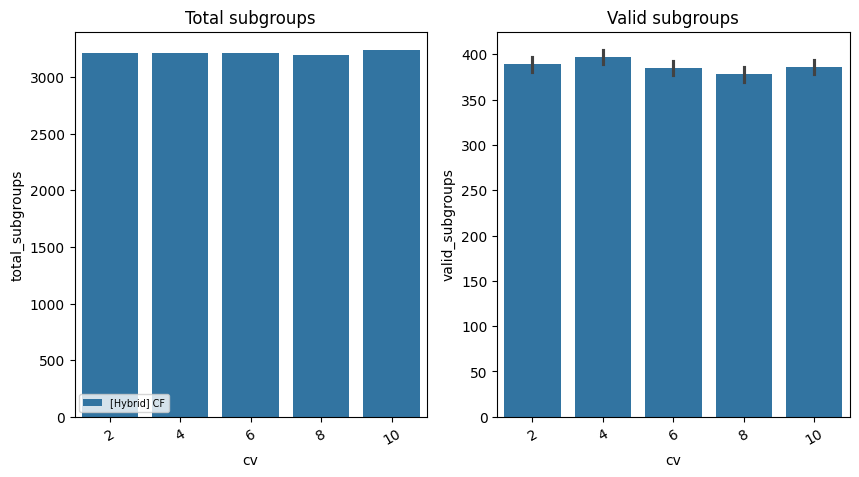

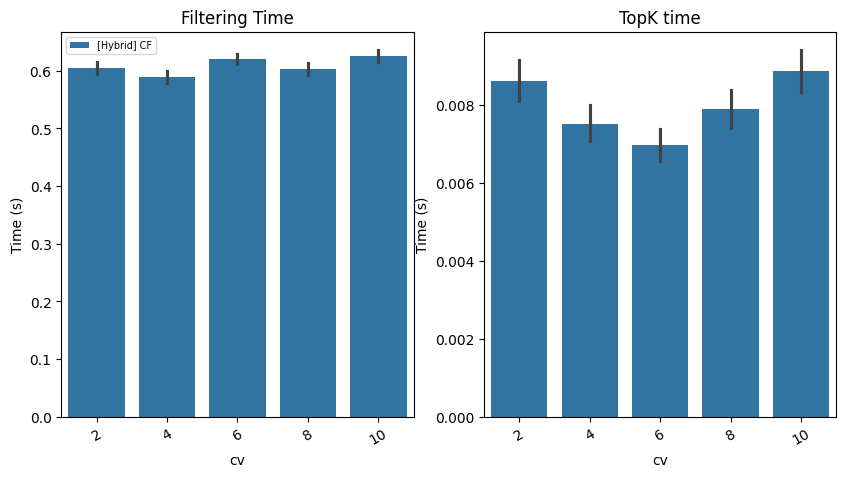

In [2]:
parameter_tuning("cv", [2, 4, 6 ,8 , 10], user_iterations=50, scanners = main_competitors)

# Tuned vs not tuned
Whether to tune the hyperparameters of the model or not.

If tuned is True, the following function is called:

> tune(Y, T, *, X=None, W=None, sample_weight=None, groups=None, params='auto')

Tunes the major hyperparameters of the final stage causal forest based on out-of-sample R-score performance. It trains small forests of size 100 trees on a grid of parameters and tests the out of sample R-score. After the function is called, then all parameters of self have been set to the optimal hyperparameters found. The estimator however remains un-fitted, so you need to call fit afterwards to fit the estimator with the chosen hyperparameters. The list of tunable parameters can be accessed via the property tunable_params.

If tuned is False, the model uses the pre-defined models for Y and T, along with the default parameters:
> model_t=RandomForestClassifier()

> model_y=WeightedLassoCVWrapper()

  0%|          | 0/2 [00:00<?, ?it/s]2024-12-20 15:58:59.803 | WARNING  | trees.topk:scan:243 - [Hybrid] CF - ConstrainedJ -  Not enough valid subgroups to satisfy max_overlap=0.5
2024-12-20 15:58:59.803 | WARNING  | trees.topk:get_topK:60 - [Hybrid] CF with ConstrainedJ - could not find 5 subgroups out of 6 valid subgroups
2024-12-20 15:58:59.847 | WARNING  | trees.topk:get_topK:54 - [Hybrid] CF with LevelBased - could not find any valid subgroups
100%|██████████| 2/2 [03:00<00:00, 90.40s/it]


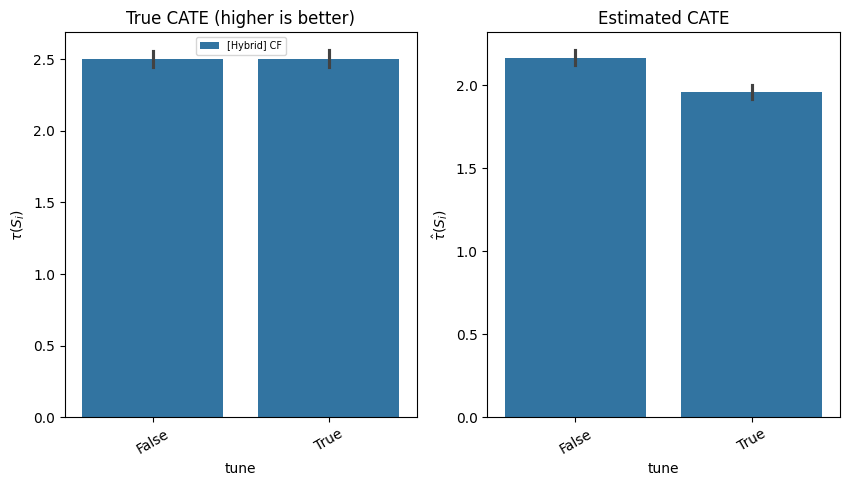

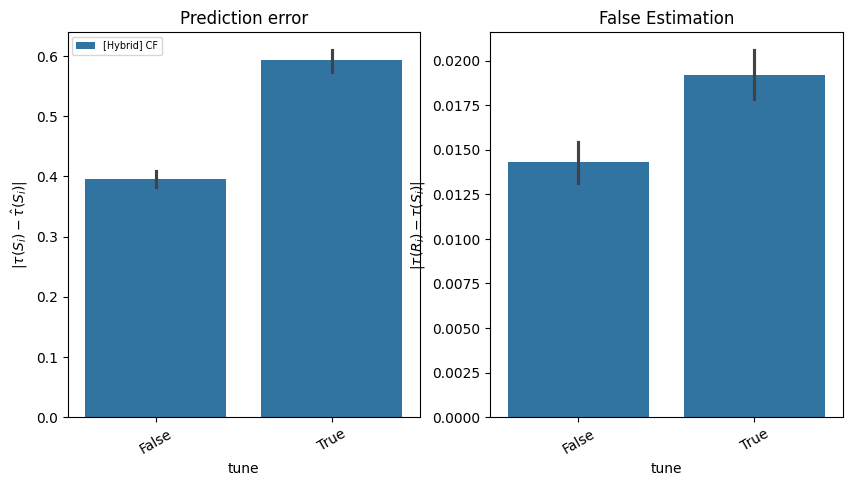

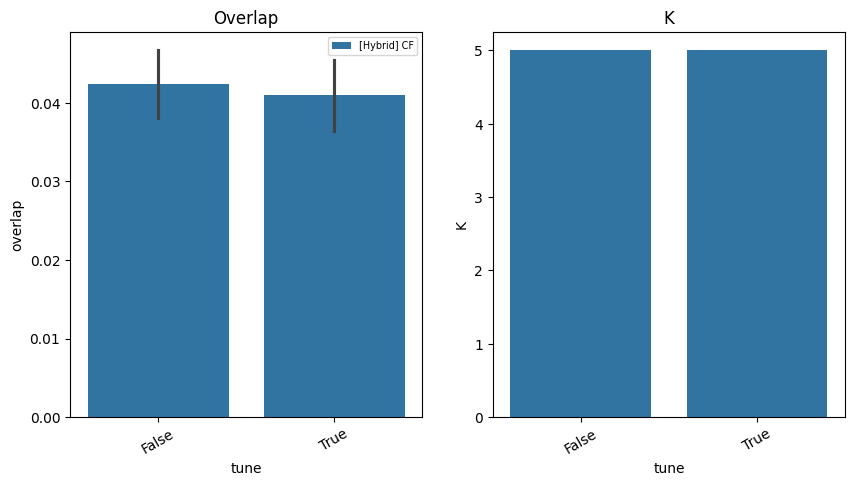

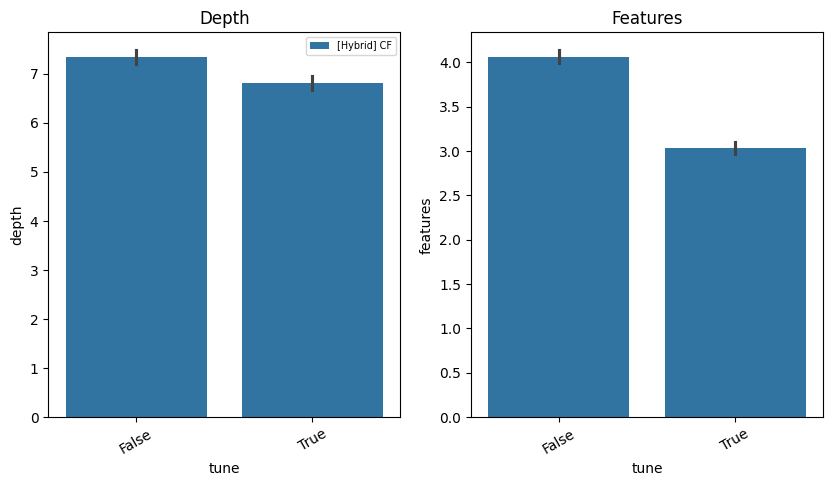

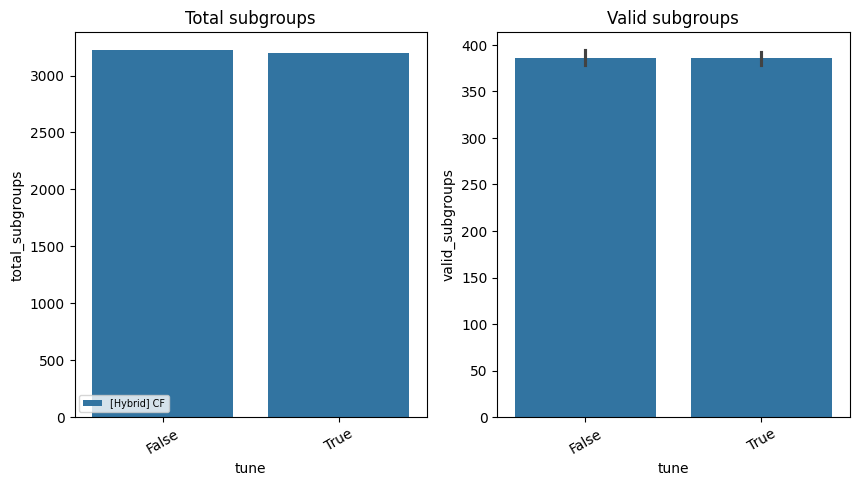

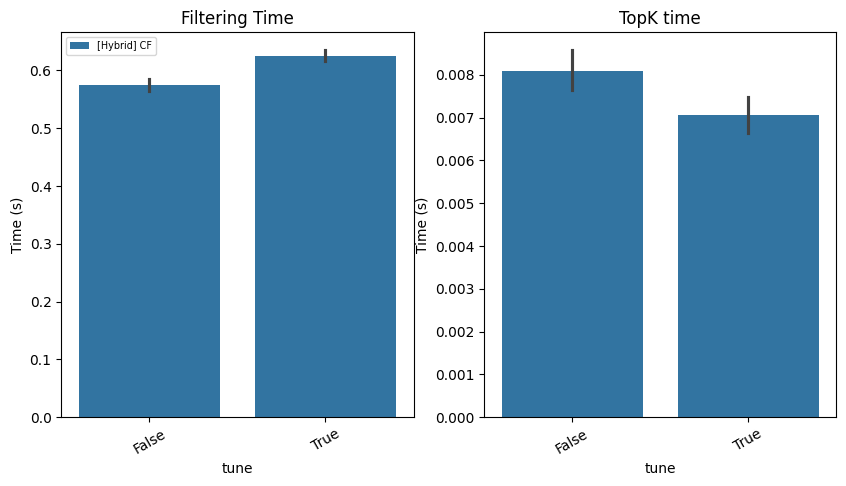

In [3]:
parameter_tuning("tune", [True, False], user_iterations=50, scanners = main_competitors)

# Criterion (mse vs het)

criterion ({"mse", "het"}, default “mse”) – The function to measure the quality of a split. Supported criteria are "mse" for the mean squared error in a linear moment estimation tree and "het" for heterogeneity score.

The "mse" criterion finds splits that minimize the score

$sum_{child} E[(Y - <theta(child), T> - beta(child))^2 | X=child] weight(child)$

Internally, for the case of more than two treatments or for the case of two treatments with fit_intercept=True then this criterion is approximated by computationally simpler variants for computational purposes. In particular, it is replaced by:

$sum_{child} weight(child) * rho(child).T @ E[(T;1) @ (T;1).T | X in child] @ rho(child)$

where:

$rho(child) := E[(T;1) @ (T;1).T | X in parent]^{-1}
                * E[(Y - <theta(x), T> - beta(x)) (T;1) | X in child]$

This can be thought as a heterogeneity inducing score, but putting more weight on scores with a large minimum eigenvalue of the child jacobian $E[(T;1) @ (T;1).T | X in child]$, which leads to smaller variance of the estimate and stronger identification of the parameters.

The “het” criterion finds splits that maximize the pure parameter heterogeneity score

$sum_{child} weight(child) * rho(child)[:n_T].T @ rho(child)[:n_T]$
This can be thought as an approximation to the ideal heterogeneity score:

$weight(left) * weight(right) || theta(left) - theta(right)||_2^2 / weight(parent)^2$
as outlined in [cfdml1]

 50%|█████     | 1/2 [03:06<03:06, 186.75s/it]2025-01-17 16:47:18.787 | WARNING  | trees.topk:get_topK:89 - [Hybrid] CF - Weighted - |t_r-t|=0.1850000000000005 are different. P: feature_6 > 0.046 Subgroup: feature_0 > 0.003 AND feature_0 > 0.917 AND feature_1 > 0.535 AND feature_0 > 1.418 AND feature_1 > 1.321 AND feature_0 > 1.696 AND feature_1 <= 1.668 AND feature_0 > 2.329
2025-01-17 16:47:18.876 | WARNING  | trees.topk:get_topK:89 - [Hybrid] CF - ConstrainedT - |t_r-t|=0.1850000000000005 are different. P: feature_6 > 0.046 Subgroup: feature_0 > 0.003 AND feature_0 > 0.917 AND feature_1 > 0.535 AND feature_0 > 1.418 AND feature_1 > 1.321 AND feature_0 > 1.696 AND feature_1 <= 1.668 AND feature_0 > 2.329
2025-01-17 16:47:38.849 | WARNING  | trees.topk:get_topK:89 - [Hybrid] CF - ConstrainedJ - |t_r-t|=0.15299999999999958 are different. P: feature_9 <= -0.223 Subgroup: feature_0 > 0.003 AND feature_0 > 0.917 AND feature_1 > 0.535 AND feature_0 > 1.418 AND feature_1 > 1.321 AND feature

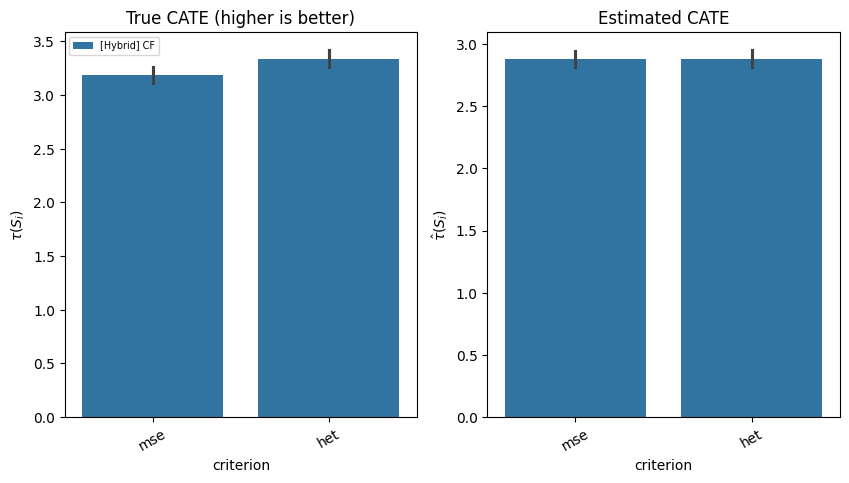

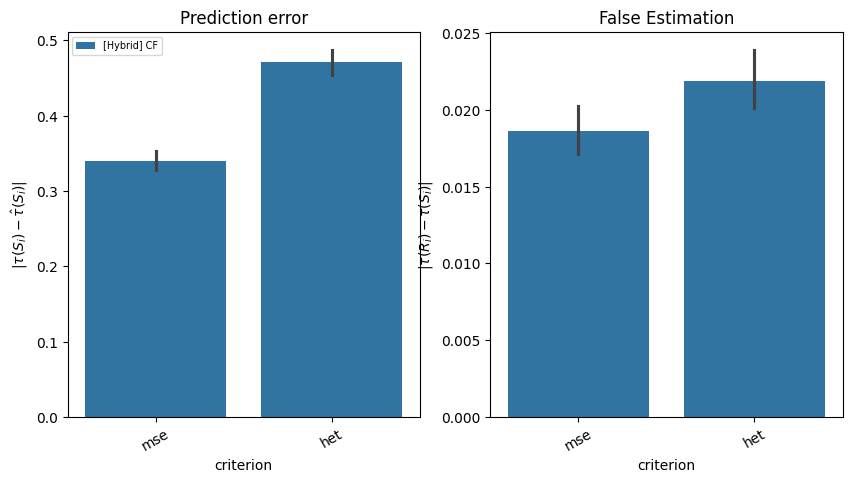

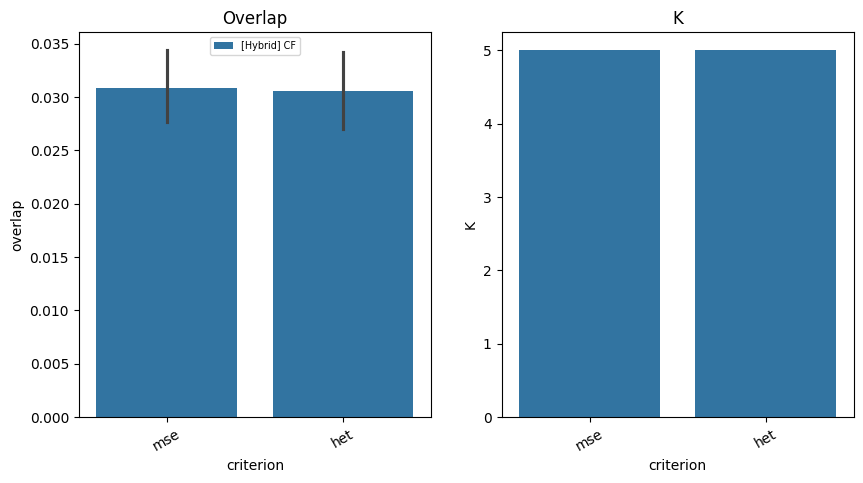

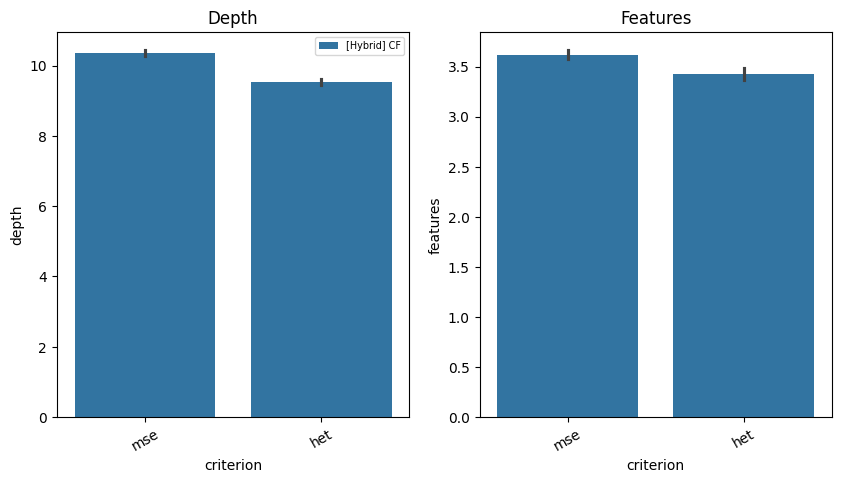

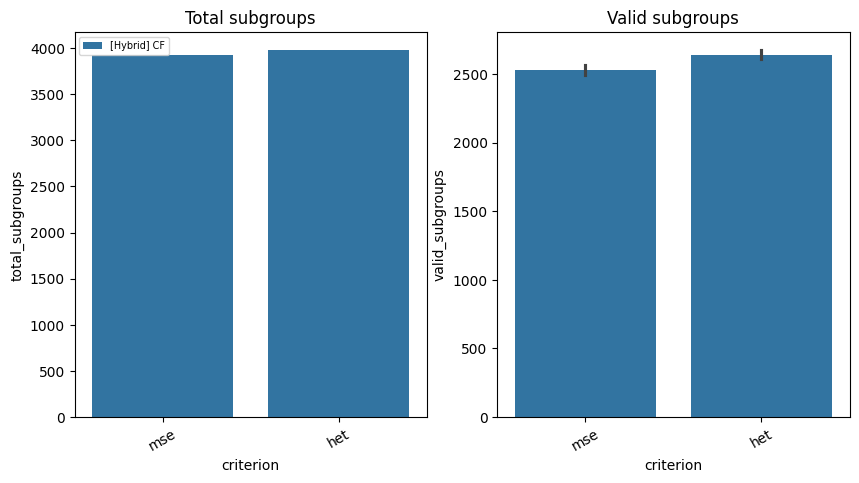

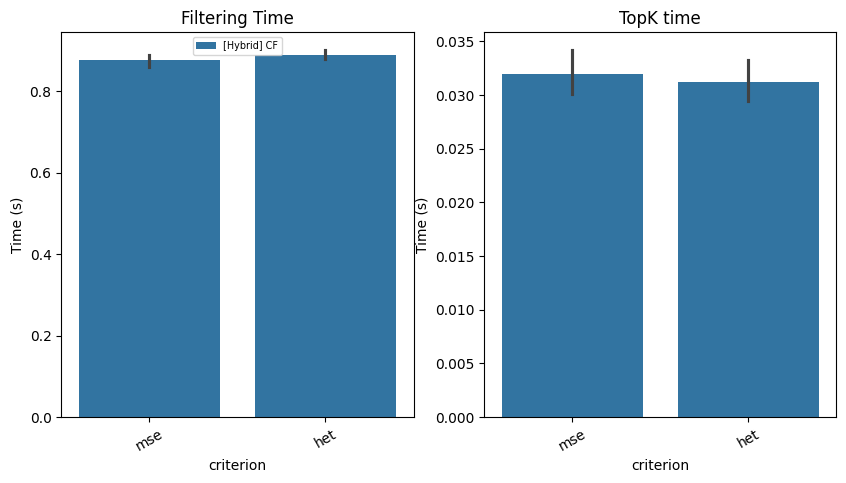

In [2]:
parameter_tuning("criterion", ["mse","het"], user_iterations=50, scanners = main_competitors)

# Number of trees
n_estimators (int, default 100)

  0%|          | 0/5 [00:00<?, ?it/s]2024-12-20 16:04:54.075 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - ConstrainedJ - |t_r-t|=0.1589999999999998 are different. P: feature_7 > 0.376 Subgroup: feature_0 > 0.461 AND feature_0 > 0.954 AND feature_1 > -0.02 AND feature_0 > 1.719
2024-12-20 16:04:54.109 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - ConstrainedT - |t_r-t|=0.1589999999999998 are different. P: feature_7 > 0.376 Subgroup: feature_0 > 0.461 AND feature_0 > 0.954 AND feature_1 > -0.02 AND feature_0 > 1.719
2024-12-20 16:04:54.144 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - Weighted - |t_r-t|=0.1589999999999998 are different. P: feature_7 > 0.376 Subgroup: feature_0 > 0.461 AND feature_0 > 0.954 AND feature_1 > -0.02 AND feature_0 > 1.719
2024-12-20 16:05:00.429 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - ConstrainedJ - |t_r-t|=0.18800000000000017 are different. P: feature_2 > -0.085 Subgroup: feature_0 > 0.461 AND feature_0 > 0.954 AND feature_1 > -

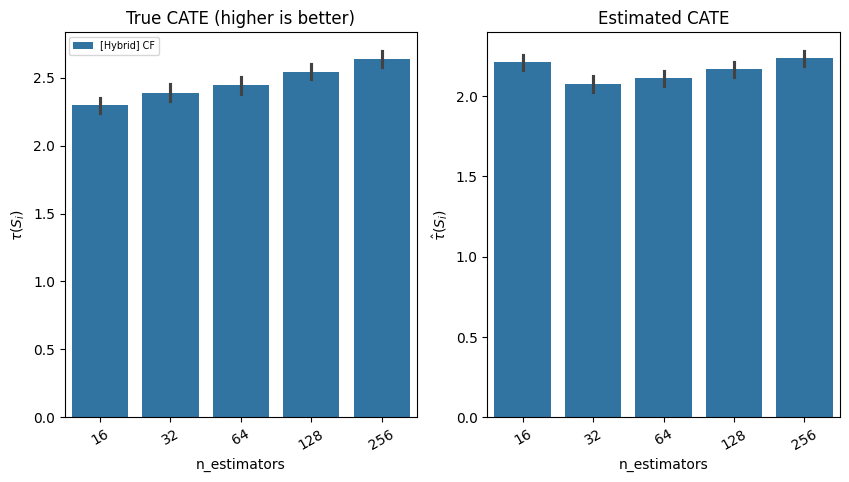

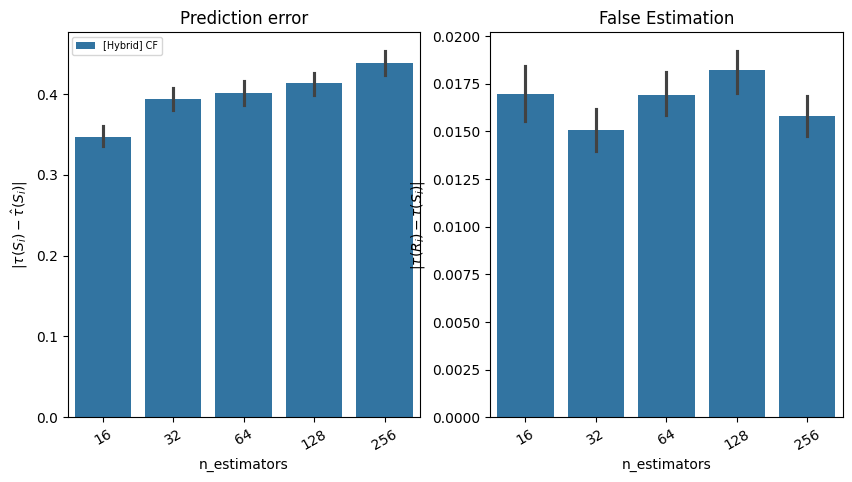

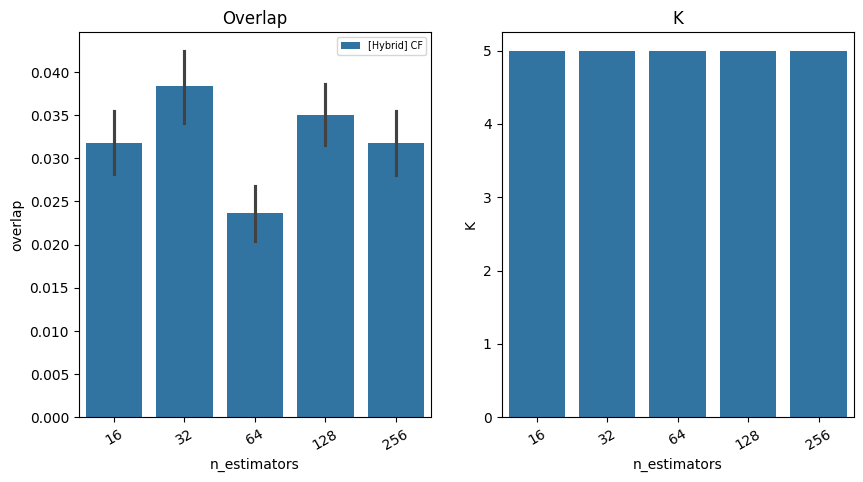

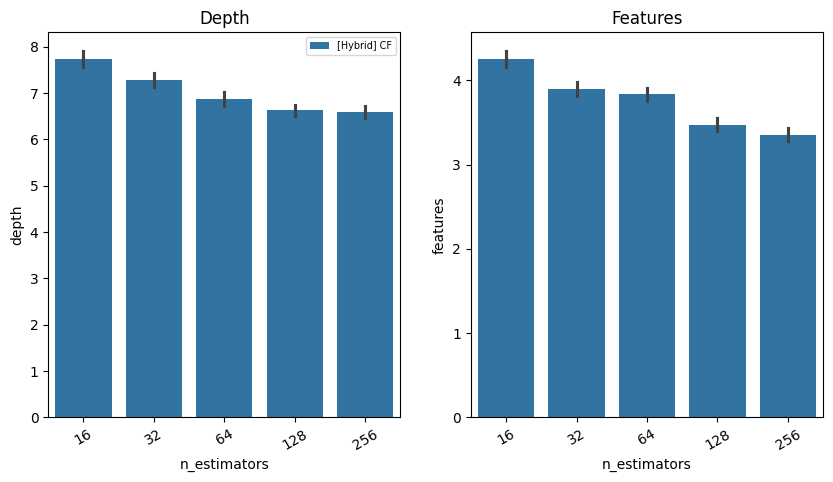

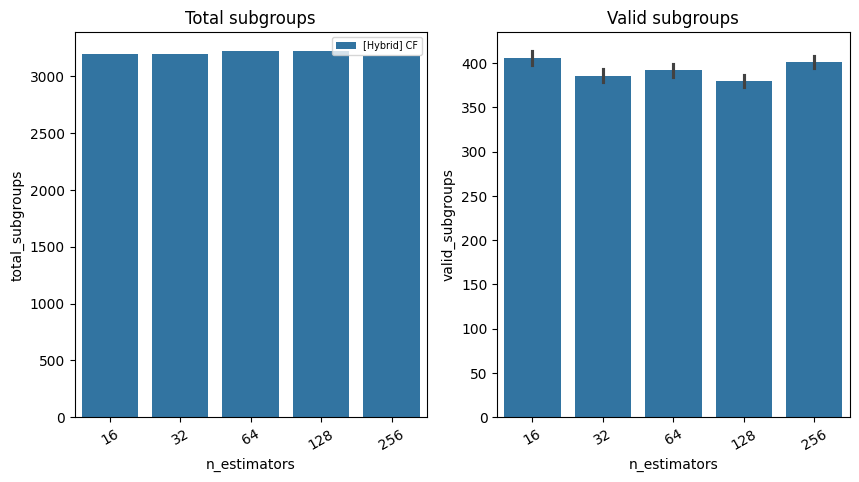

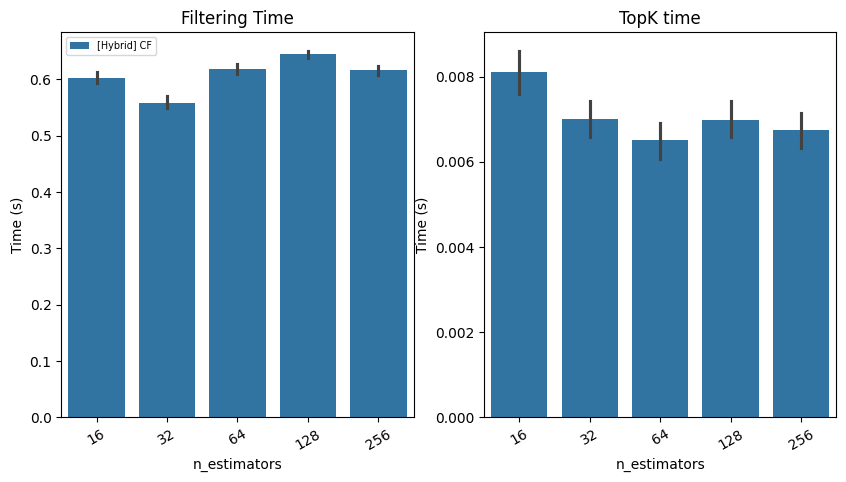

In [5]:
parameter_tuning("n_estimators", [16, 32, 64, 128, 256], user_iterations=50, scanners = main_competitors)

# Minimum samples required to split
min_samples_split (int or float, default 10) – The minimum number of samples required to split an internal node:

If int, then consider min_samples_split as the minimum number.

If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split.

 50%|█████     | 2/4 [02:53<02:53, 86.89s/it]2024-12-20 16:34:09.356 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - ConstrainedT - |t_r-t|=0.19599999999999973 are different. P: feature_5 <= -0.198 Subgroup: feature_0 > 0.436 AND feature_0 > 1.043 AND feature_1 > 0.394 AND feature_1 > 1.379 AND feature_9 > 0.049
2024-12-20 16:34:09.387 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - Weighted - |t_r-t|=0.19599999999999973 are different. P: feature_5 <= -0.198 Subgroup: feature_0 > 0.436 AND feature_0 > 1.043 AND feature_1 > 0.394 AND feature_1 > 1.379 AND feature_9 > 0.049
2024-12-20 16:34:09.402 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - LevelBased - |t_r-t|=0.19599999999999973 are different. P: feature_5 <= -0.198 Subgroup: feature_0 > 0.436 AND feature_0 > 1.043 AND feature_1 > 0.394 AND feature_1 > 1.379 AND feature_9 > 0.049
2024-12-20 16:34:21.858 | WARNING  | trees.topk:get_topK:54 - [Hybrid] CF with LevelBased - could not find any valid subgroups
2024-12-20 16:3

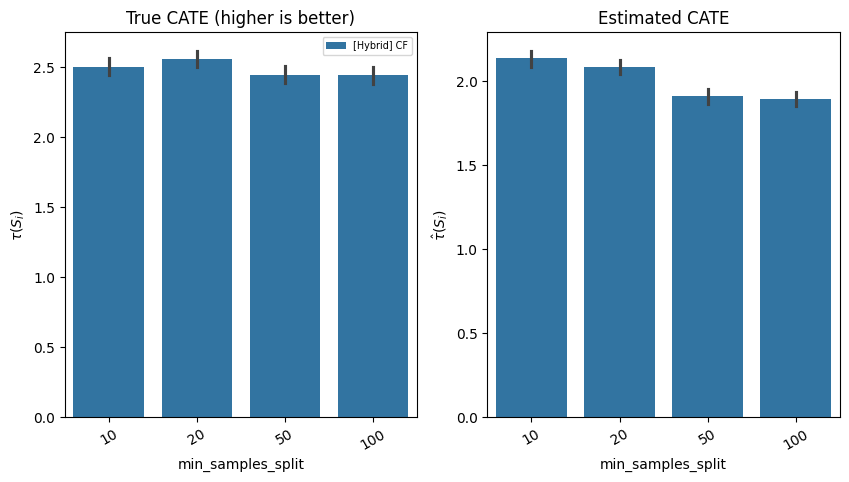

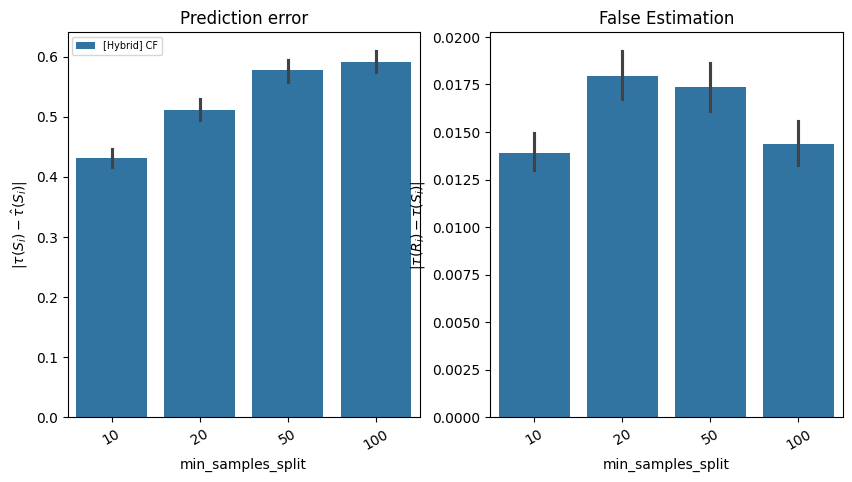

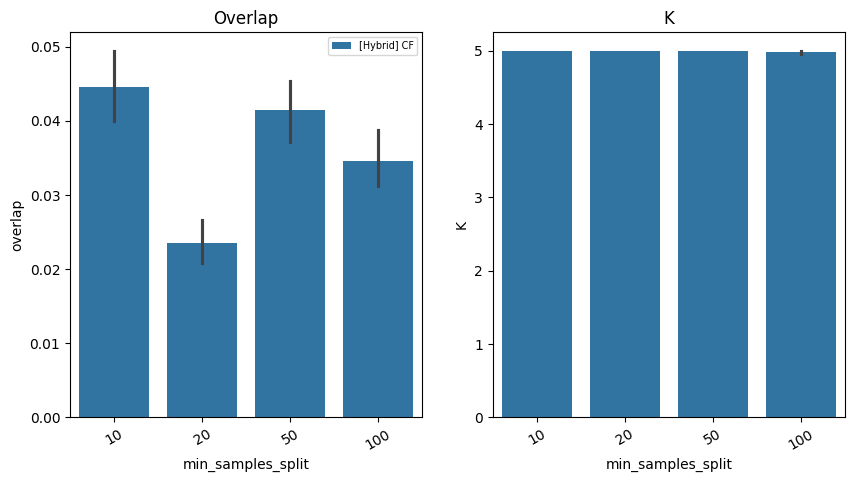

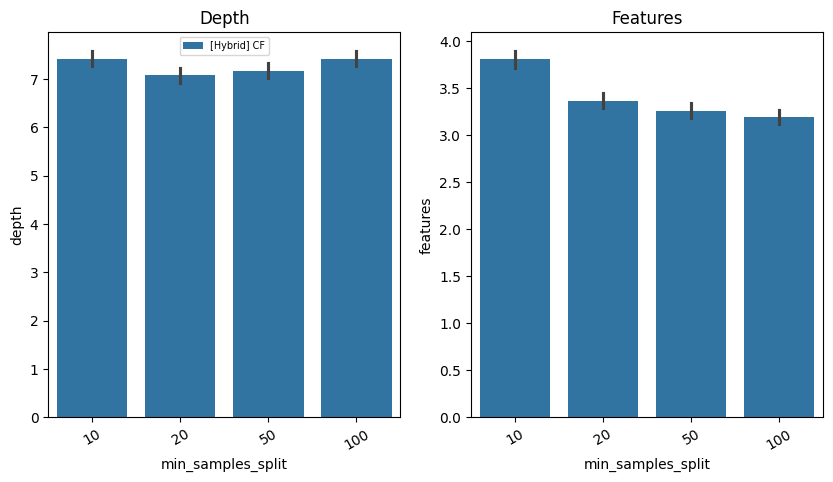

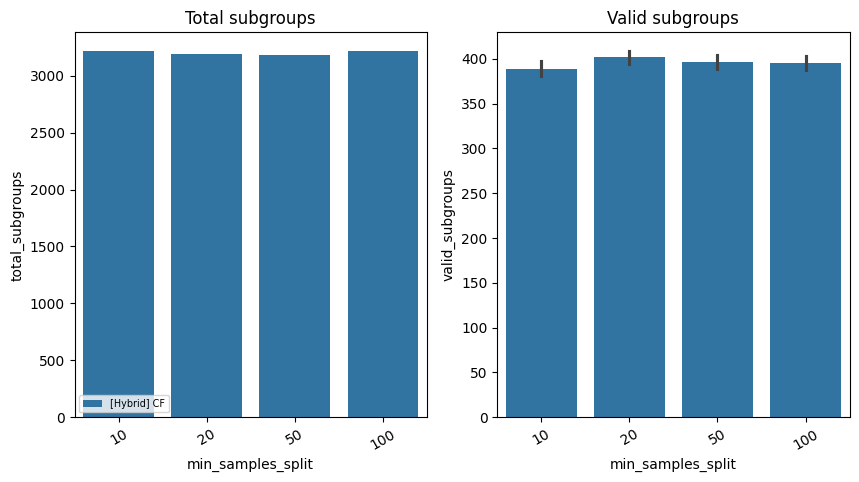

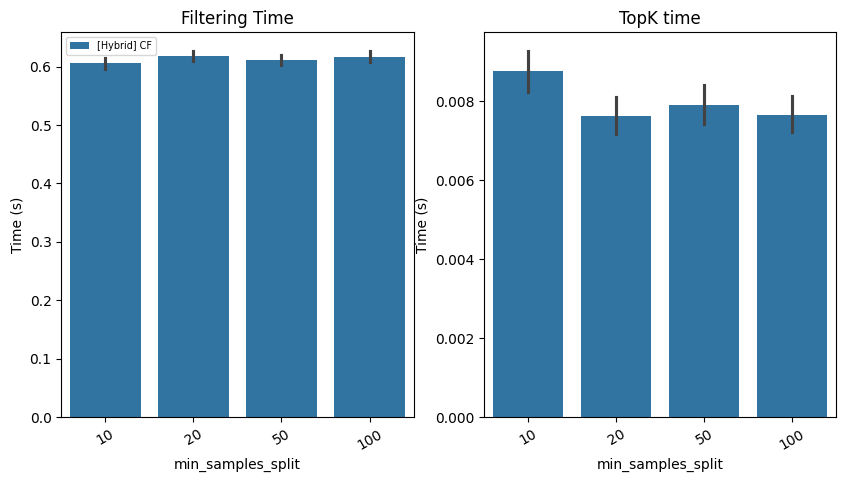

In [10]:
parameter_tuning("min_samples_split", [10, 20, 50, 100],  user_iterations=50, scanners = main_competitors)

# Minimum samples required at a leaf node
min_samples_leaf (int or float, default 5) – The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

If int, then consider min_samples_leaf as the minimum number.

If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.


 60%|██████    | 3/5 [02:23<01:19, 39.88s/it]2024-12-20 16:18:11.387 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - ConstrainedJ - |t_r-t|=0.16999999999999993 are different. P: feature_7 <= 1.999 AND feature_7 > 0.024 Subgroup: feature_0 > 0.436 AND feature_1 > 0.473 AND feature_0 > 0.674 AND feature_1 > 1.088 AND feature_1 > 1.338 AND feature_3 > 0.242
2024-12-20 16:18:11.404 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - ConstrainedT - |t_r-t|=0.16999999999999993 are different. P: feature_7 <= 1.999 AND feature_7 > 0.024 Subgroup: feature_0 > 0.436 AND feature_1 > 0.473 AND feature_0 > 0.674 AND feature_1 > 1.088 AND feature_1 > 1.338 AND feature_3 > 0.242
2024-12-20 16:18:11.422 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - Weighted - |t_r-t|=0.16999999999999993 are different. P: feature_7 <= 1.999 AND feature_7 > 0.024 Subgroup: feature_0 > 0.436 AND feature_1 > 0.473 AND feature_0 > 0.674 AND feature_1 > 1.088 AND feature_1 > 1.338 AND feature_3 > 0.242
2024-12-20 

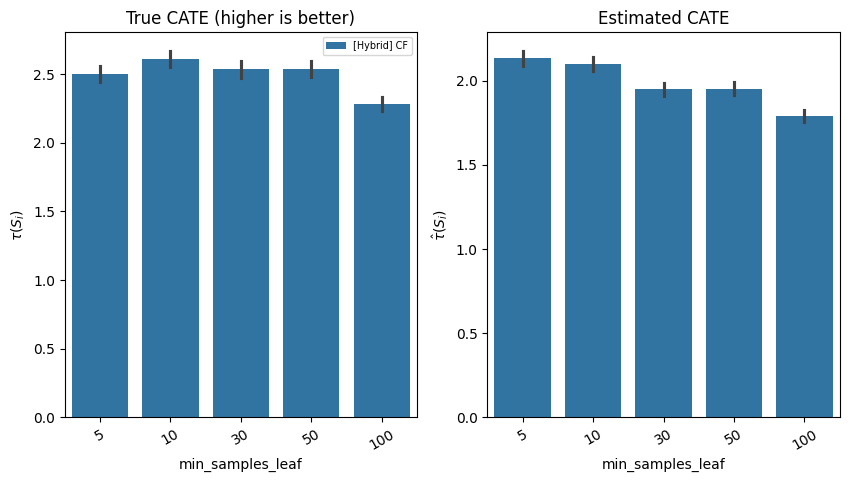

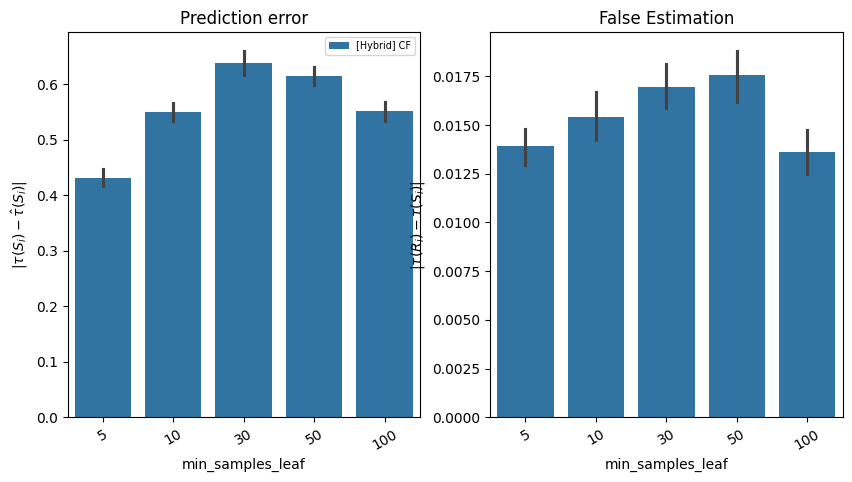

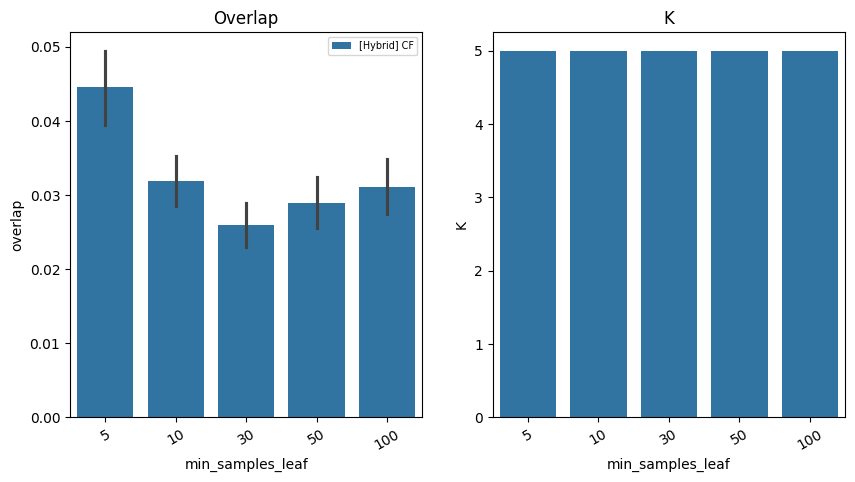

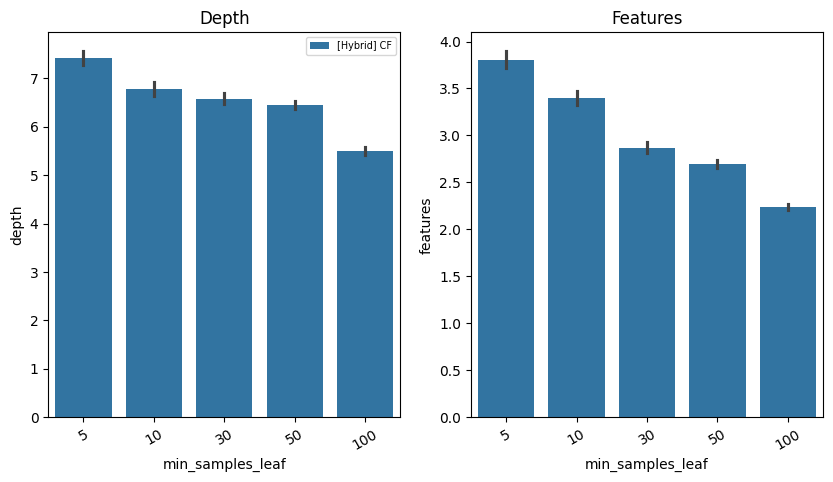

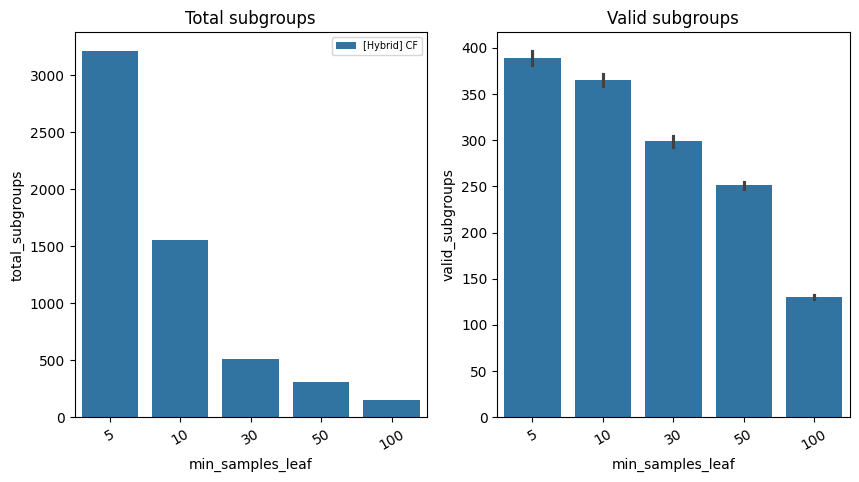

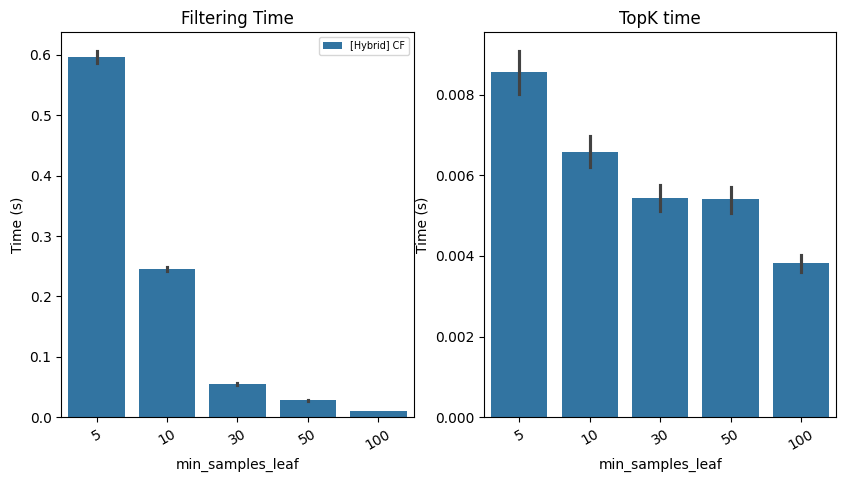

In [7]:
parameter_tuning("min_samples_leaf", [5, 10, 30, 50, 100], user_iterations=50, scanners = main_competitors)

# Maximum tree depth
max_depth (int, default None)

If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

100%|██████████| 6/6 [22:16<00:00, 222.68s/it]
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


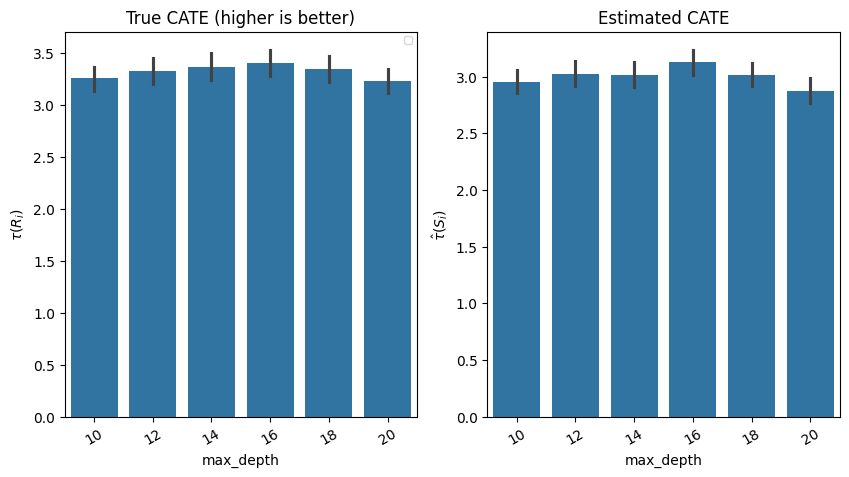

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


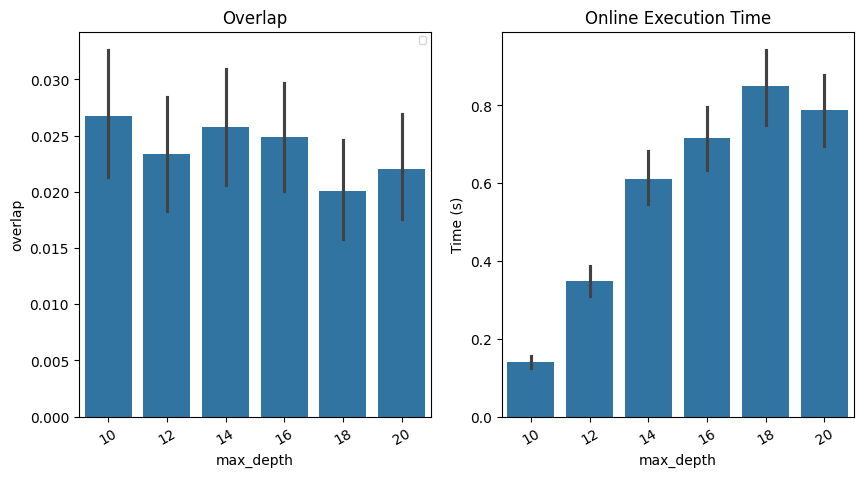

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


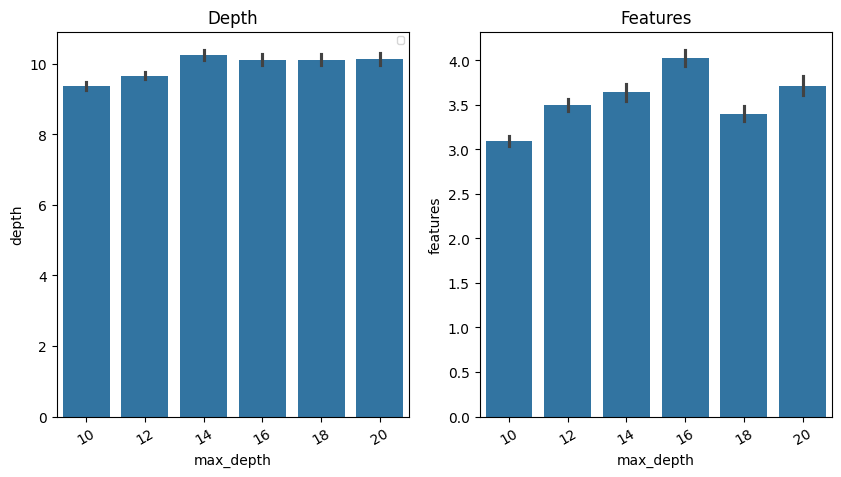

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


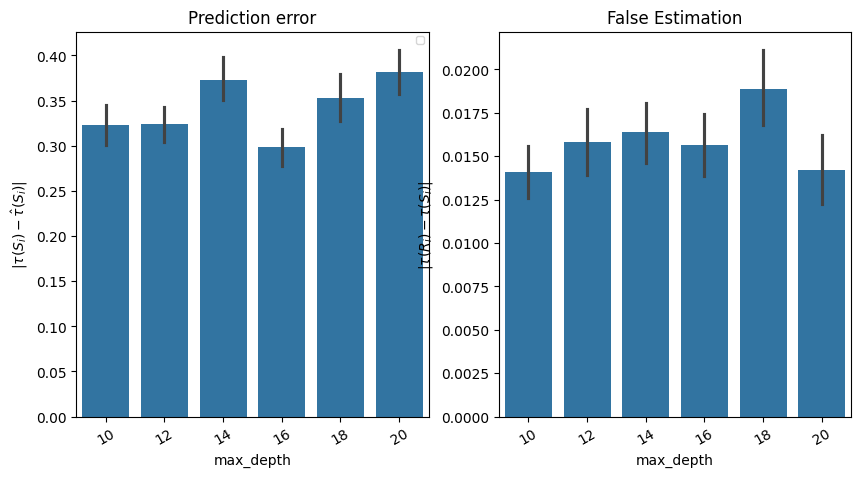

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


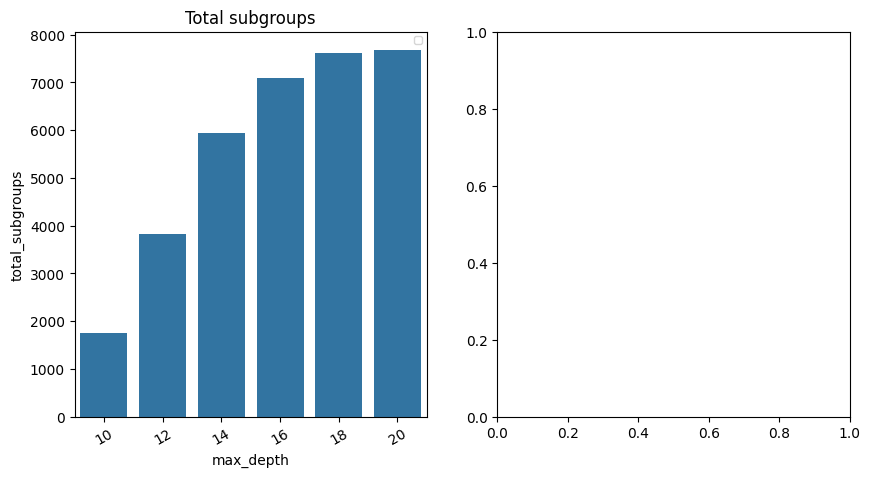

In [2]:
parameter_tuning("max_depth", [10, 12, 14, 16, 18, 20], user_iterations=20, scanners = main_competitors)

 67%|██████▋   | 4/6 [12:46<07:13, 216.71s/it]2025-01-30 17:41:45.618 | WARNING  | trees.topk:get_topK:74 - [Pretrained] CF - OptRes - |t_r-t|=0.17300000000000004 are different. P: feature_4 > -0.069 Subgroup: feature_0 > -0.04429 AND feature_0 > 0.91962 AND feature_1 > 0.53575 AND feature_0 > 1.41931 AND feature_1 > 0.95876 AND feature_1 > 1.57154 AND feature_2 <= -0.14657 AND feature_0 > 1.52050 AND feature_1 > 1.92776
2025-01-30 17:41:48.344 | WARNING  | trees.topk:get_topK:74 - [Pretrained] CF - ResOve - |t_r-t|=0.17300000000000004 are different. P: feature_4 > -0.069 Subgroup: feature_0 > -0.04429 AND feature_0 > 0.91962 AND feature_1 > 0.53575 AND feature_0 > 1.41931 AND feature_1 > 0.95876 AND feature_1 > 1.57154 AND feature_2 <= -0.14657 AND feature_0 > 1.52050 AND feature_1 > 1.92776
2025-01-30 17:41:48.537 | WARNING  | trees.topk:get_topK:74 - [Pretrained] CF - NoOve - |t_r-t|=0.17300000000000004 are different. P: feature_4 > -0.069 Subgroup: feature_0 > -0.04429 AND feature_

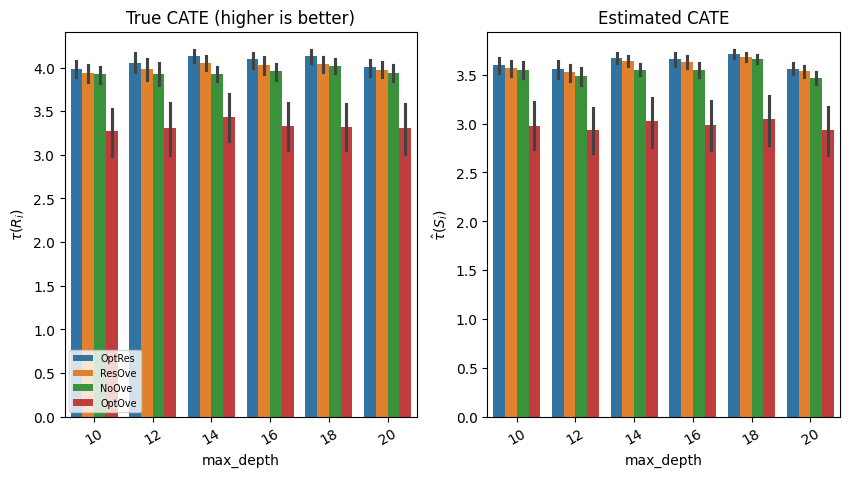

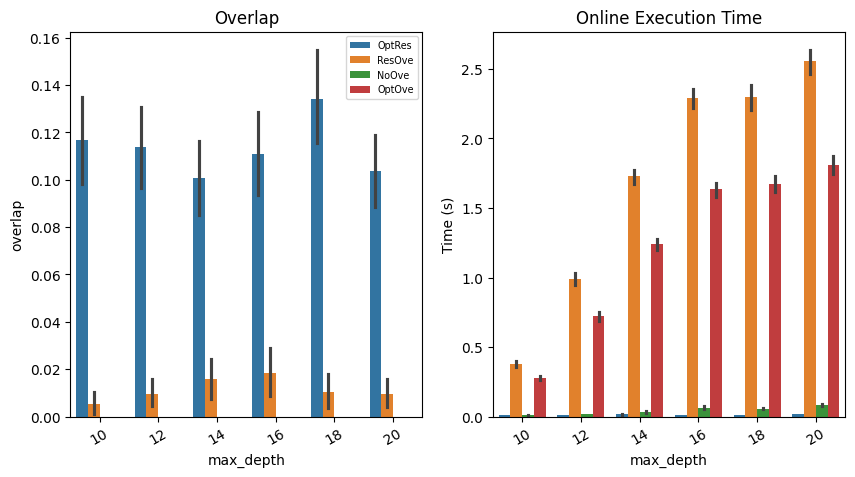

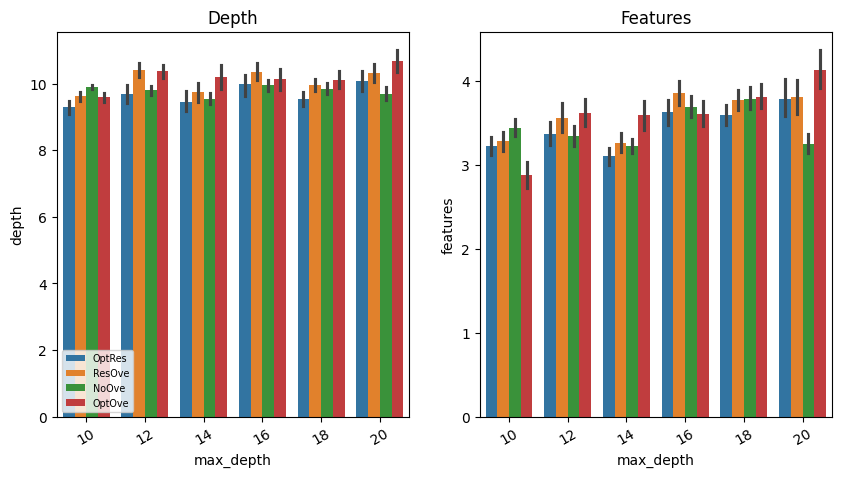

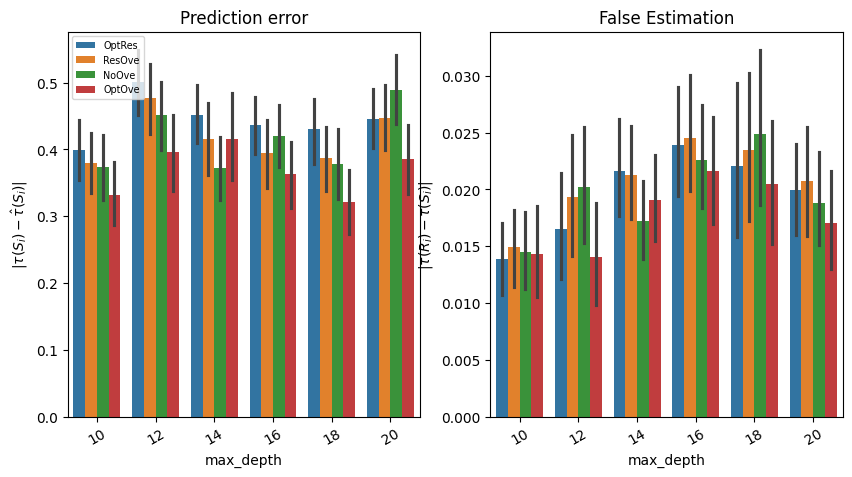

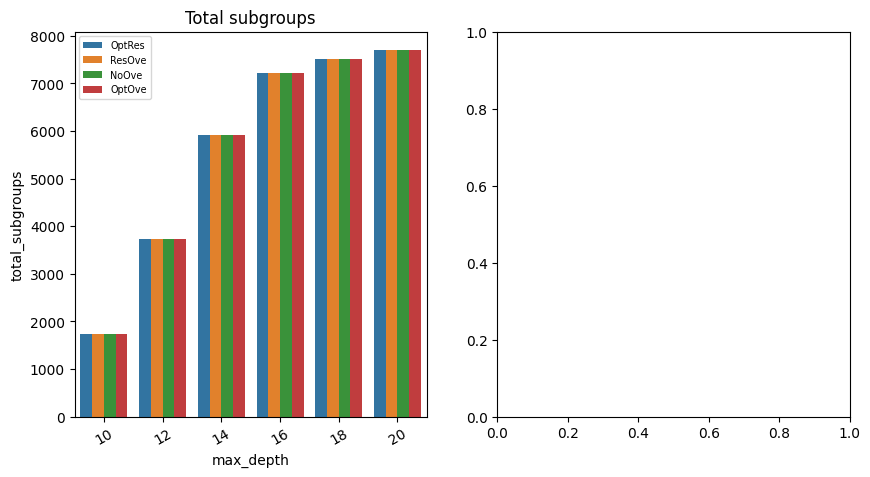

In [4]:
parameter_tuning("max_depth", [10, 12, 14, 16, 18, 20], user_iterations=20, scanners = main_no_random, hue="topK_algorithm")

  0%|          | 0/7 [00:00<?, ?it/s]2024-12-20 16:36:03.579 | WARNING  | trees.topk:scan:243 - [Hybrid] CF - ConstrainedJ -  Not enough valid subgroups to satisfy max_overlap=0.5
2024-12-20 16:36:03.579 | WARNING  | trees.topk:get_topK:60 - [Hybrid] CF with ConstrainedJ - could not find 5 subgroups out of 6 valid subgroups
2024-12-20 16:36:03.589 | WARNING  | trees.topk:get_topK:54 - [Hybrid] CF with LevelBased - could not find any valid subgroups
2024-12-20 16:36:03.597 | WARNING  | trees.topk:get_topK:41 - [Hybrid] CF - No valid subgroups - skipping topK
2024-12-20 16:36:03.598 | WARNING  | trees.topk:get_topK:41 - [Hybrid] CF - No valid subgroups - skipping topK
2024-12-20 16:36:03.599 | WARNING  | trees.topk:get_topK:41 - [Hybrid] CF - No valid subgroups - skipping topK
2024-12-20 16:36:03.600 | WARNING  | trees.topk:get_topK:41 - [Hybrid] CF - No valid subgroups - skipping topK
2024-12-20 16:36:03.601 | WARNING  | trees.topk:get_topK:41 - [Hybrid] CF - No valid subgroups - skippi

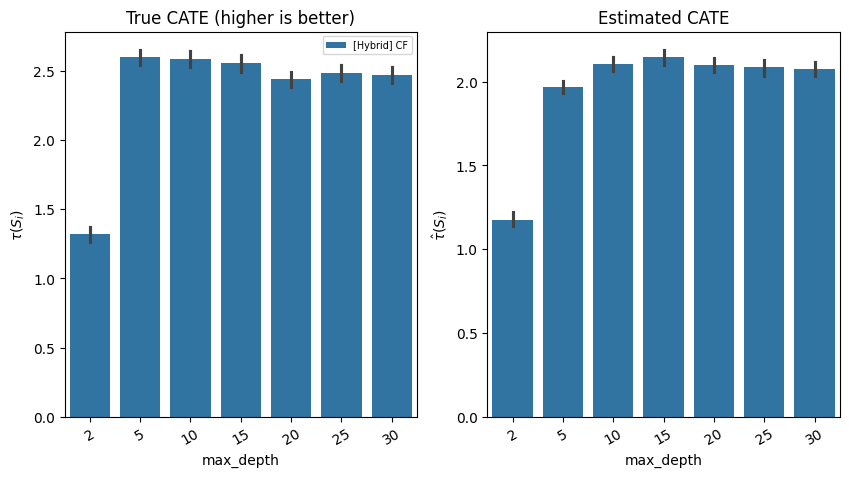

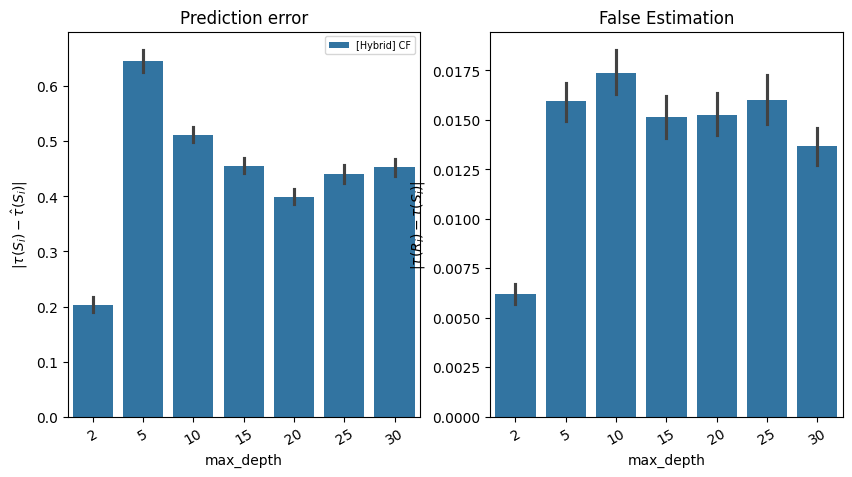

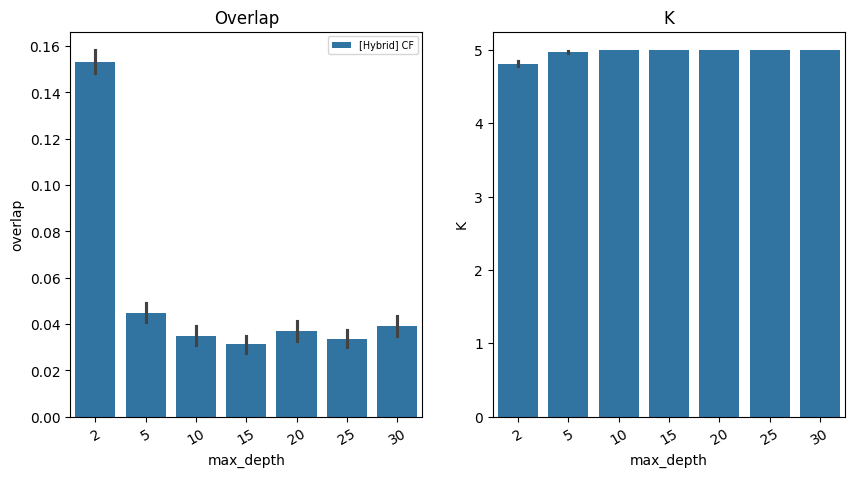

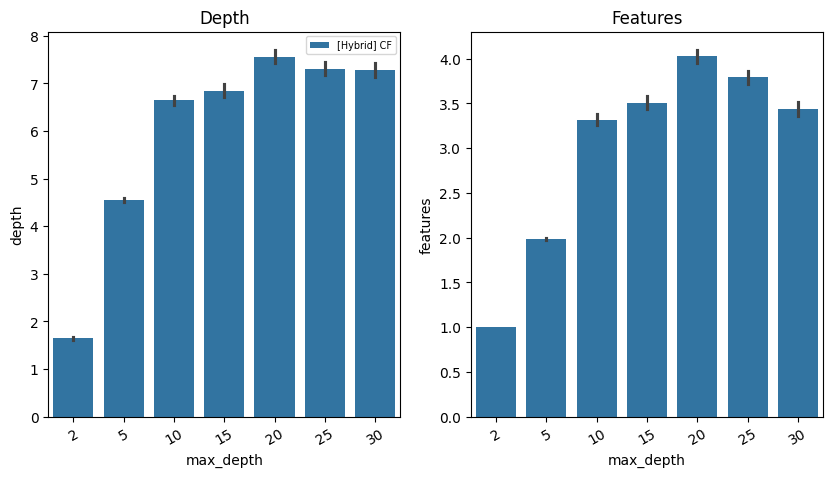

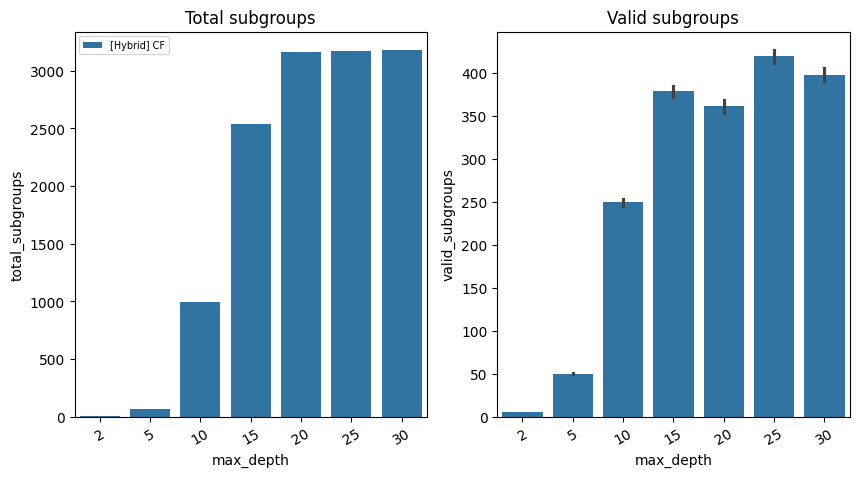

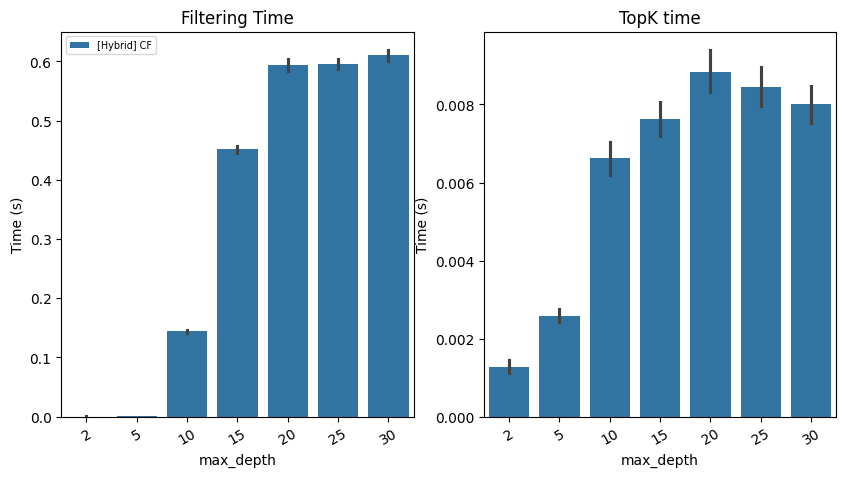

In [11]:
parameter_tuning("max_depth", [2, 5, 10, 15, 20, 25, 30], user_iterations=50, scanners = main_competitors)

# Maximum features to consider for split
max_features : int, float, {"auto", "sqrt", "log2"}, or None, default None

The number of features to consider when looking for the best split:

- If int, then consider `max_features` features at each split.
- If float, then `max_features` is a fraction and `int(max_features * n_features)` features
    are considered at each split.
- If "auto", then `max_features=n_features`.
- If "sqrt", then `max_features=sqrt(n_features)`.
- If "log2", then `max_features=log2(n_features)`.
- If None, then `max_features=n_features`.

  0%|          | 0/4 [00:00<?, ?it/s]2024-12-20 16:25:35.135 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - ConstrainedJ - |t_r-t|=0.1509999999999998 are different. P: feature_3 > 0.302 AND feature_5 <= 2.726 Subgroup: feature_0 > 0.349 AND feature_0 <= 0.93 AND feature_1 > 1.265 AND feature_1 > 1.5 AND feature_0 > 0.487
2024-12-20 16:25:35.190 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - Weighted - |t_r-t|=0.1509999999999998 are different. P: feature_3 > 0.302 AND feature_5 <= 2.726 Subgroup: feature_0 > 0.349 AND feature_0 <= 0.93 AND feature_1 > 1.265 AND feature_1 > 1.5 AND feature_0 > 0.487
 25%|██▌       | 1/4 [01:34<04:43, 94.47s/it]2024-12-20 16:26:53.439 | WARNING  | trees.topk:get_topK:54 - [Hybrid] CF with LevelBased - could not find any valid subgroups
2024-12-20 16:26:55.061 | WARNING  | trees.topk:get_topK:87 - [Hybrid] CF - ConstrainedJ - |t_r-t|=0.15100000000000025 are different. P: feature_3 > 0.342 AND feature_9 > -1.653 Subgroup: feature_0 > 0.467 AND fea

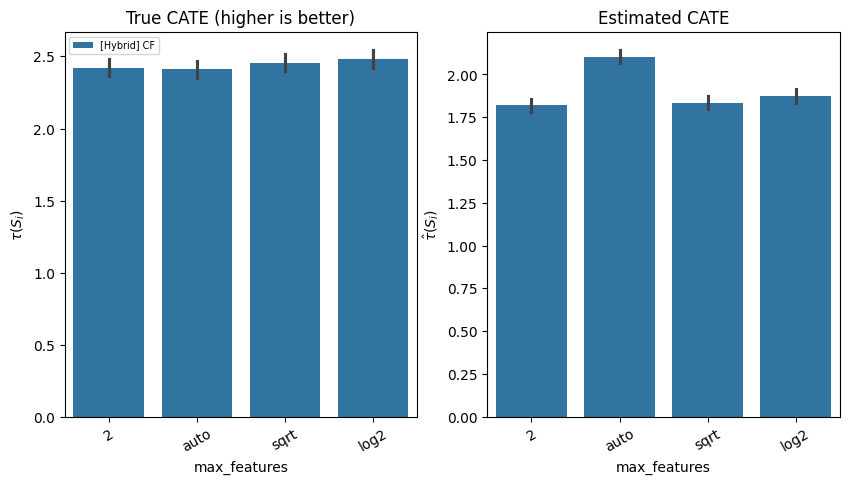

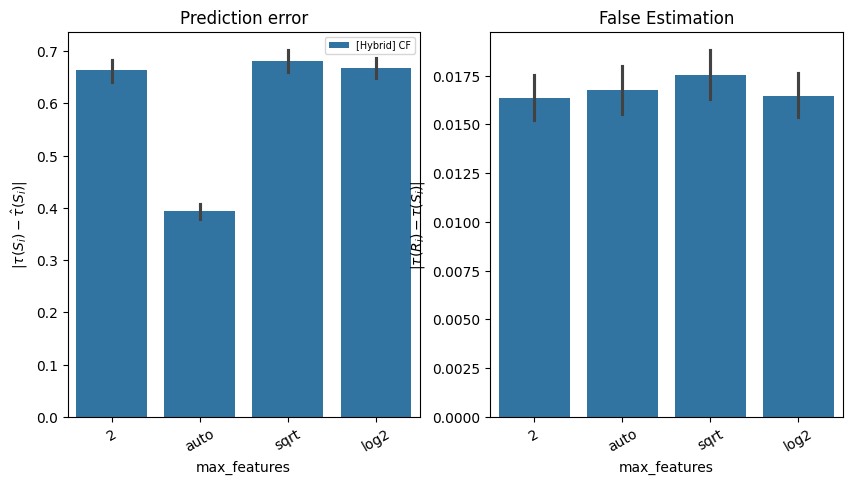

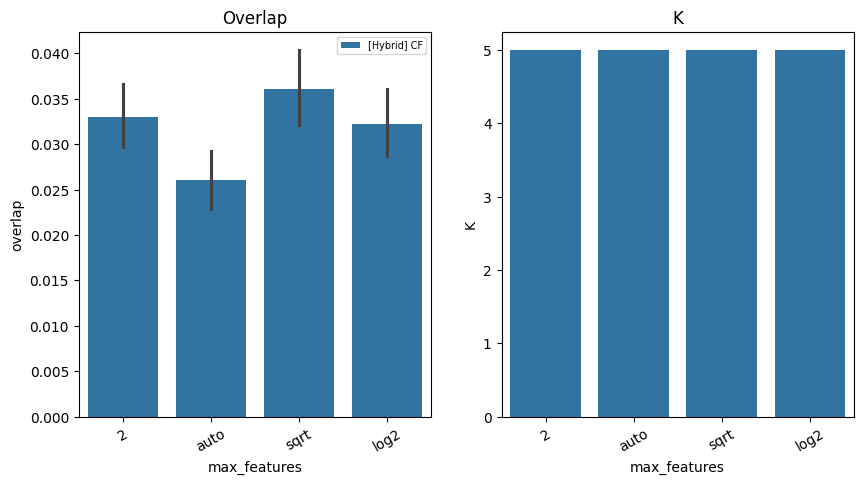

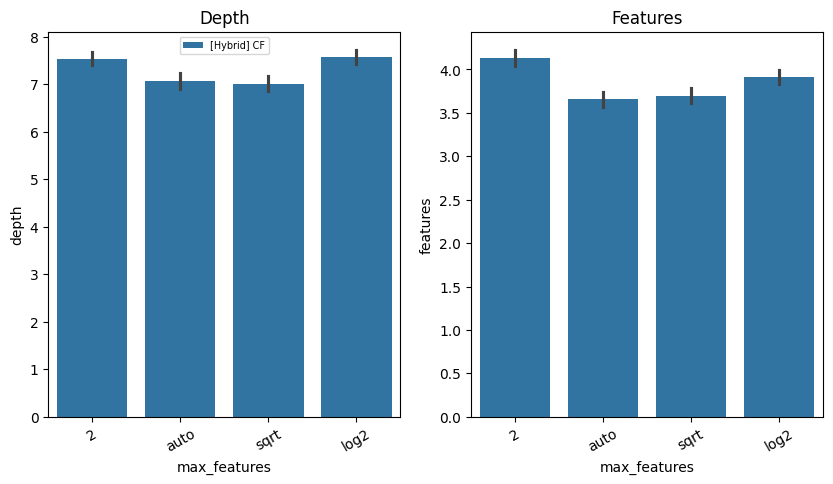

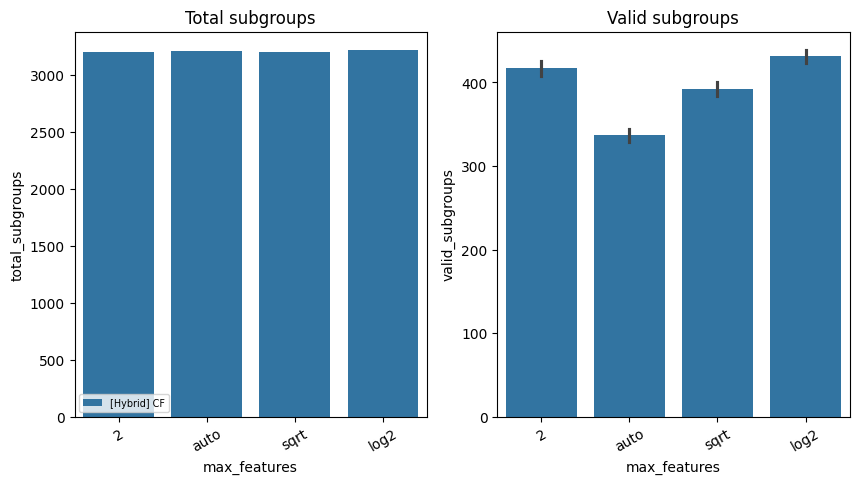

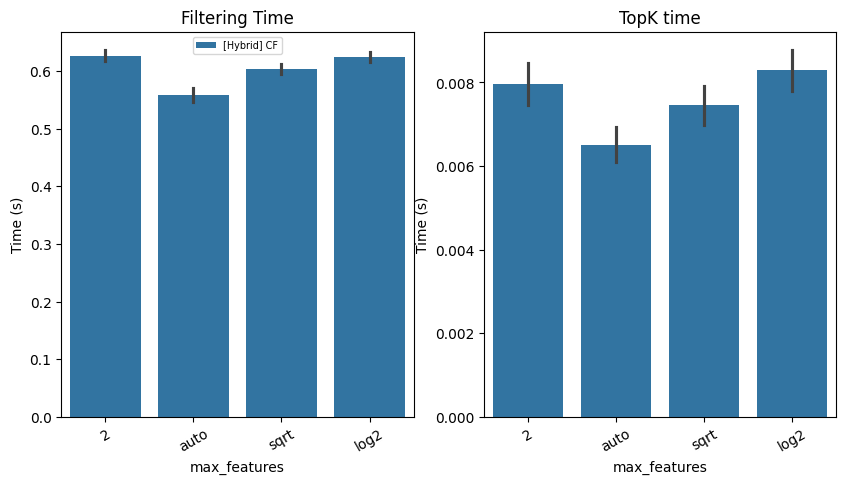

In [9]:
parameter_tuning("max_features", [2,'auto','sqrt','log2'], user_iterations=50, scanners = main_competitors)